# Introduction to TensorFlow and Keras

අපි කලින් notebooks වලදී Neural Networks මුල සිට (from scratch) හැදුවා. Forward pass, backward pass (backpropagation), gradients හැමදෙයක්ම අපි අතින් code කළා.

නමුත් ප්‍රායෝගිකව (production level එකේදී) අපි ඒ හැමදෙයක්ම අතින් code කරන්නේ නැහැ. ඒ වෙනුවට අපි **TensorFlow** හෝ **PyTorch** වැනි Deep Learning frameworks භාවිතා කරනවා.

මේ notebook එකෙන් අපි TensorFlow (සහ එහි high-level API එක වන Keras) භාවිතා කරලා ඉතාමත් පහසුවෙන් Neural Network එකක් හදන්නේ කොහොමද කියලා ඉගෙන ගමු.

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.21.0


## 1. What is a Tensor? (Tensor එකක් කියන්නේ මොකක්ද?)

TensorFlow වල මූලිකම දත්ත ඒකකය (data structure) වෙන්නේ Tensor එකයි. Tensor එකක් කියන්නේ සාමාන්‍ය Numpy array එකක් වගේම දෙයක්. හැබැයි Tensors වලට විශේෂ හැකියාවන් තියෙනවා:
1. ඒවාට GPU/TPU මත වේගයෙන් ධාවනය වෙන්න පුළුවන්.
2. ඒවාට Gradients (අවකලන) ස්වයංක්‍රීයව ගණනය කිරීමේ හැකියාව තියෙනවා (Auto-differentiation).

In [3]:
# Scalar (0-D Tensor)
scalar = tf.constant(7)
print("Scalar:", scalar)

# Vector (1-D Tensor)
vector = tf.constant([10, 10])
print("\nVector:", vector)

# Matrix (2-D Tensor)
matrix = tf.constant([[1, 2], [3, 4]])
print("\nMatrix:\n", matrix)

Scalar: tf.Tensor(7, shape=(), dtype=int32)

Vector: tf.Tensor([10 10], shape=(2,), dtype=int32)

Matrix:
 tf.Tensor(
[[1 2]
 [3 4]], shape=(2, 2), dtype=int32)


## 2. Building a Neural Network with Keras

Keras කියන්නේ TensorFlow ඇතුලේ තියෙන ඉතා සරල API එකක්. Keras මගින් අපිට layers එකතු කරලා ලේසියෙන්ම model එකක් හදාගන්න පුළුවන්.

අපි කලින් කරපු XOR ප්‍රශ්නය වගේ සරල ගැටලුවකට model එකක් හදමු:
- Input layer: Features 2යි
- Hidden layer: Neurons 4යි, Activation = ReLU
- Output layer: Neuron 1යි, Activation = Sigmoid

In [4]:
# Sequential API භාවිතයෙන් Model එකක් සෑදීම
model = tf.keras.Sequential([
    # Hidden layer එක (neurons 4යි, input_shape එක 2යි මන්ද අපිට features 2ක් ඇති නිසා)
    tf.keras.layers.Dense(units=4, activation='relu', input_shape=(2,)),
    
    # Output layer එක (neuron 1යි, 0 සහ 1 අතර අගයක් ගන්න sigmoid භාවිතා කරයි)
    tf.keras.layers.Dense(units=1, activation='sigmoid')
])

# Model එකේ සැකැස්ම බැලීමට
model.summary()

/Users/adithyabandara/miniconda3/envs/stt/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17 (68.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)

ඉහත `model.summary()` මගින් අපිට පෙන්වනවා model එකේ තියෙන parameters (weights සහ biases) ගණන.
- Hidden layer: (2 inputs * 4 weights) + 4 biases = 12 parameters
- Output layer: (4 inputs * 1 weight) + 1 bias = 5 parameters
- Total parameters = 17

## 3. Compiling the Model (Model එක Compile කිරීම)

Model එකක් train කරන්න කලින් අපි ඒකට දේවල් 3ක් කියන්න ඕනේ:
1. **Loss Function:** වැරැද්ද මනින්නේ කොහොමද? (උදා: Binary Crossentropy)
2. **Optimizer:** Weights update කරන්නේ කොහොමද? (උදා: SGD, Adam) අපි කලින් කරපු Gradient Descent වල දියුණු කරපු version එකක් තමයි Adam කියන්නේ.
3. **Metrics:** සාර්ථකත්වය මනින්නේ කොහොමද? (උදා: Accuracy)

In [5]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss='binary_crossentropy',  # Binary classification සඳහා සුදුසුම loss එක
    metrics=['accuracy']
)
print("Model compiled successfully!")

Model compiled successfully!


## 4. Training the Model (Model එක Train කිරීම)

අපි dummy dataset එකක් (XOR වගේ) හදලා අපේ model එක train කරමු. Keras වලදී training සම්පූර්ණයෙන්ම කරන්නේ `model.fit()` කියන function එකෙන්. අපි අතින් ලියපු forward pass, backward pass ඔක්කොම මේ function එක ඇතුළේ ස්වයංක්‍රීයව සිද්ධ වෙනවා.

In [6]:
# Training Data (XOR ගැටලුව)
X_train = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=np.float32)

y_train = np.array([[0], [1], [1], [0]], dtype=np.float32)

# Model එක train කිරීම
# epochs = සම්පූර්ණ dataset එක කී වතාවක් network එක හරහා යවනවාද යන්න
history = model.fit(X_train, y_train, epochs=500, verbose=0)  # verbose=0 මගින් output එක සැඟවීමට පුළුවන්

print("Training complete!")

Training complete!


## 5. Visualizing the Training Process

`model.fit()` මගින් return කරන `history` object එකේ අපේ loss එක සහ accuracy එක epoch එකෙන් epoch එකට වෙනස් වුණ විදිහ සටහන් වෙලා තියෙනවා.

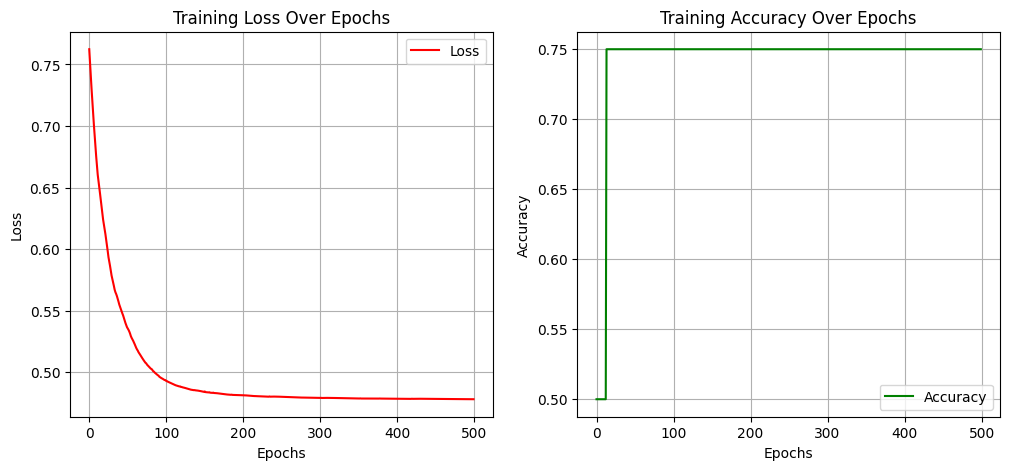

In [7]:
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Loss', color='red')
plt.title('Training Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Accuracy', color='green')
plt.title('Training Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

plt.show()

## 6. Making Predictions

දැන් අපි අපේ model එක test කරලා බලමු. Prediction එකක් ගන්න පාවිච්චි කරන්නේ `model.predict()`.

In [8]:
predictions = model.predict(X_train)

print("\n--- Predictions ---")
for i in range(len(X_train)):
    print(f"Input: {X_train[i]} => Predicted: {predictions[i][0]:.4f} (Rounded: {round(predictions[i][0])}) | Actual: {y_train[i][0]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

--- Predictions ---
Input: [0. 0.] => Predicted: 0.3342 (Rounded: 0) | Actual: 0.0
Input: [0. 1.] => Predicted: 0.3342 (Rounded: 0) | Actual: 1.0
Input: [1. 0.] => Predicted: 0.9974 (Rounded: 1) | Actual: 1.0
Input: [1. 1.] => Predicted: 0.3342 (Rounded: 0) | Actual: 0.0


## Summary (සාරාංශය)

TensorFlow/Keras භාවිතයෙන් අපිට ඉතාමත් පහසුවෙන් Neural Network එකක් හදන්න පුළුවන්. පියවර මෙහෙමයි:
1. `tf.keras.Sequential` මගින් model එක සෑදීම (Layers එකතු කිරීම).
2. `model.compile` මගින් Loss function එක සහ Optimizer එක ලබා දීම.
3. `model.fit` මගින් Data ලබා දී Model එක Train කිරීම.
4. `model.predict` මගින් අලුත් දත්ත සඳහා පිළිතුරු ලබා ගැනීම.

අපි From Scratch ලියපු lines 100කට වැඩි code එක මෙතනදී පේළි 5-10කින් ලියන්න පුළුවන් වුණා. නිෂ්පාදන මට්ටමේ (production level) වැඩ වලදී සෑමවිටම මේ වගේ framework එකක් භාවිතා කරනවා.